# Data Exploration and target variable part-1

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv("Transformed_Housing_Data2.csv")
data.head()

,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
0,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,0,...,0,0,0,0,0,0,0,0,0,0
1,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,400,...,0,0,1,0,0,0,0,0,0,0
2,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,0,...,0,0,1,0,0,0,0,0,0,0
3,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,910,...,0,0,0,1,0,0,0,0,0,0
4,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,0,...,0,0,0,0,1,0,0,0,0,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sale_Price                                 21609 non-null  float64
 1   No of Bedrooms                             21609 non-null  int64  
 2   No of Bathrooms                            21609 non-null  float64
 3   Flat Area (in Sqft)                        21609 non-null  float64
 4   Lot Area (in Sqft)                         21609 non-null  float64
 5   No of Floors                               21609 non-null  float64
 6   No of Times Visited                        21609 non-null  int64  
 7   Overall Grade                              21609 non-null  int64  
 8   Area of the House from Basement (in Sqft)  21609 non-null  float64
 9   Basement Area (in Sqft)                    21609 non-null  int64  
 10  Age of House (in Years

In [3]:
data['Sale_Price'].head(10)

0     221900.0
1     538000.0
2     180000.0
3     604000.0
4     510000.0
5    1129575.0
6     257500.0
7     291850.0
8     229500.0
9     323000.0
Name: Sale_Price, dtype: float64

In [4]:
data['Sale_Price'].tail(10)

21599     507250.0
21600     429000.0
21601     610685.0
21602    1010000.0
21603     475000.0
21604     360000.0
21605     400000.0
21606     402101.0
21607     400000.0
21608     325000.0
Name: Sale_Price, dtype: float64

In [5]:
data['Sale_Price'].describe()

count    2.160900e+04
mean     5.116186e+05
std      2.500620e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      1.129575e+06
Name: Sale_Price, dtype: float64

# Data Exploration- Target variable part-2

An outier is a data point that is distinct from other data points.Its value lies outside the usual range of rest of the values in the data and hence the term 'outlier'

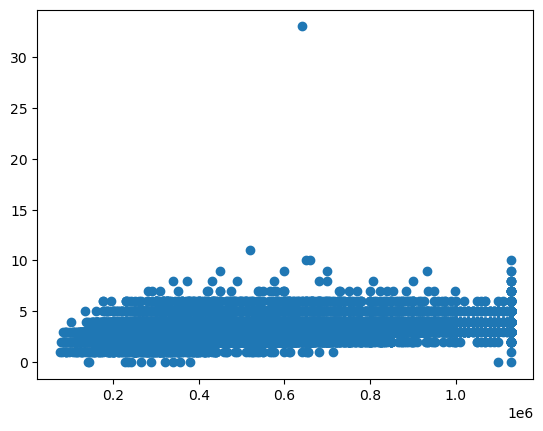

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=data['Sale_Price'],y=data['No of Bedrooms'])

<Axes: xlabel='Sale_Price'>

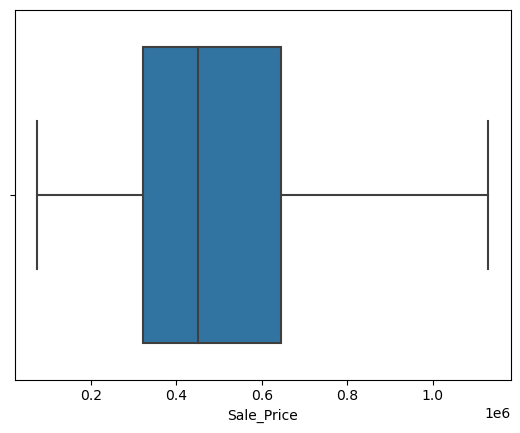

In [7]:
import seaborn as sns
# can ignore missing values
sns.boxplot(x=data['Sale_Price'])

# Data Exploration and targer variable part-3

Different ways of treating outlier:

1--> Deletion: The entire row containing outliers is removed.Data size is reduced.If dataset is small then valuable information in the process is    lost, hence not advisiable to do it.

2-->Impuation:Outlier are not removed but replaced with average/mean/median/mode value

3--> Data Transformation: The variable is transformed to its log value or the square or cube root.

4-->Binning: Different bins are formed based on the values of the variable to treat the outliers.

In [8]:
q1 = data["Sale_Price"].quantile(0.25)
q3 = data["Sale_Price"].quantile(0.75)
iqr = q3-q1
iqr

323050.0

In [9]:
upper_limit = q3+1.5*iqr
lower_limit = q1-1.5*iqr
upper_limit,lower_limit

(1129575.0, -162625.0)

In [14]:
def limit_imputer(value):
  if value==upper_limit:
    return upper_limit
  else:
    return value
data['Sale_Price'] = data['Sale_Price'].apply(limit_imputer)
data['Sale_Price'].describe()

count    2.160900e+04
mean     5.116186e+05
std      2.500620e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      1.129575e+06
Name: Sale_Price, dtype: float64

Still mean is greater than mode(50%) therefore Outliers still exist.

The data is not normally distributed and a bit skewed towards lower value.

# Data Exploration and target variable part 4

Treating missing values.

1)Deletion
2)Imputation

In [16]:
data.dropna(inplace=True,axis=0,subset=['Sale_Price'])
data
# But in our dataset we don't have any not null value

,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
0,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,0,...,0,0,0,0,0,0,0,0,0,0
1,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,400,...,0,0,1,0,0,0,0,0,0,0
2,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,0,...,0,0,1,0,0,0,0,0,0,0
3,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,910,...,0,0,0,1,0,0,0,0,0,0
4,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21604,360000.0,3,2.50,1530.0,1131.0,3.0,0,8,1530.0,0,...,0,0,0,1,0,0,0,0,0,0
21605,400000.0,4,2.50,2310.0,5813.0,2.0,0,8,2310.0,0,...,0,1,0,0,0,0,0,0,0,0
21606,402101.0,2,0.75,1020.0,1350.0,2.0,0,7,1020.0,0,...,0,0,0,1,0,0,0,0,0,0
21607,400000.0,3,2.50,1600.0,2388.0,2.0,0,8,1600.0,0,...,0,0,0,0,1,0,0,0,0,0


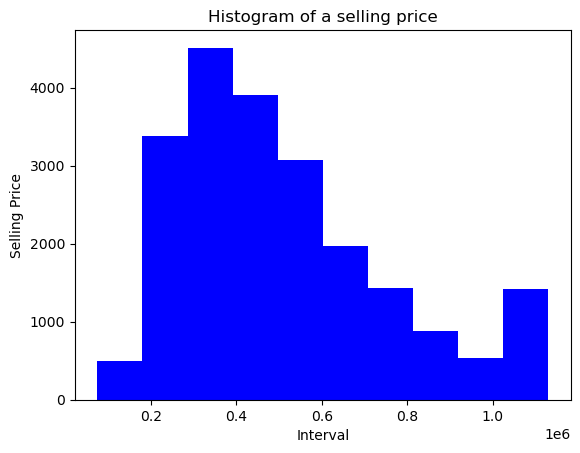

In [17]:
# Plot a histogram
plt.hist(data["Sale_Price"],bins=10,color="blue")
plt.xlabel("Interval")
plt.ylabel("Selling Price")
plt.title("Histogram of a selling price")
plt.show()

Data is skewed towards lower value

# Data exploration- Independent numerical variable part-1

In [2]:
numerical_columns = ['No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)']
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan,strategy='median')
data[numerical_columns] = imputer.fit_transform(data[numerical_columns])
     

NameError: name 'np' is not defined